In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as ops
import math
import cv2
import ast


import glob
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets

In [2]:
H_SHAPE = 768
W_SHAPE = 512

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  # set device to gpu or cpu
device

device(type='cuda', index=0)

In [4]:
!pip install paddlepaddle
!apt install tesseract-ocr -y
!apt install tesseract-ocr-vie -y
!pip install pytesseract Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-vie
0 upgraded, 1 newly installed, 0 to remove and 30 not upgraded.
Need to get 417 kB of archives.
After this operation, 546 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-vie all 1:4.00~git30-7274cfa-1.1 [417 kB]
Fetched

# split function

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as ops
import math
import cv2
import ast


import glob
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets

In [6]:
class Resnet_FPN_split(nn.Module):
    def __init__(self,out_channels = 128):
        super(Resnet_FPN_split, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.to(device)
        self.layer_1 = nn.Sequential(*list(self.resnet.children())[:4])
        self.layer_2 = self.resnet.layer2
        self.layer_3 = self.resnet.layer3
        self.layer_4 = self.resnet.layer4

        self.lateral4 = nn.Conv2d(512, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral3 = nn.Conv2d(256, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral2 = nn.Conv2d(128, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral1 = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

        self.output4 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output1 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        if (torch.isnan(x).any()):
            print("error at Resnet_FPN")
        c1 = self.layer_1(x)
        if (torch.any(torch.isnan(c1))):
            print('error resnet ')
        c2 = self.layer_2(c1)
        c3 = self.layer_3(c2)
        c4 = self.layer_4(c3)

        p4 = self.lateral4(c4)
        p3 = self.lateral3(c3) + F.interpolate(p4, scale_factor=2, mode='nearest')
        p2 = self.lateral2(c2) + F.interpolate(p3, scale_factor=2, mode='nearest')
        p1 = self.lateral1(c1) + F.interpolate(p2, scale_factor=2, mode='nearest')

        p4 = self.output4(p4)
        p3 = self.output3(p3)
        p2 = self.output2(p2)
        p1 = self.output1(p1)

        return p1, p2, p3, p4

In [7]:
class transferlayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(transferlayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        x = self.conv(x)
        return x

In [8]:
class mess_passing_H(nn.Module):
    def __init__(self, in_channels = 32, out_channels= 32):
        super(mess_passing_H, self).__init__()
        self.t2d_layers = nn.Conv2d(in_channels, out_channels, kernel_size=[1,9], stride=(1,1), padding=(0,4))
        self.d2t_layers = nn.Conv2d(in_channels, out_channels, kernel_size=[1,9], stride=(1,1), padding=(0,4))
        self.relu = nn.ReLU()
    def forward(self, x):
        nB, c, h, w = x.shape
        feature_list_old = []
        feature_list_new = []
        for cnt in range(h):
            feature_list_old.append(x[:,:,cnt,:].unsqueeze(dim = 2))
        feature_list_new.append(x[:,:,0,:].unsqueeze(dim = 2))
        feature = self.t2d_layers(feature_list_old[0])
        feature = self.relu(feature) + feature_list_old[1]
        feature_list_new.append(feature)
        for cnt in range(2,h):
            feature =  self.t2d_layers(feature_list_new[cnt-1])
            feature = self.relu(feature) + feature_list_old[cnt]
            feature_list_new.append(feature)
        feature_list_new.append(feature)
        feature_list_old = feature_list_new
        feature_list_new = []
        length = h - 1
        feature_list_new.append(feature_list_old[length])
        feature = self.d2t_layers(feature_list_old[length])
        feature = self.relu(feature) + feature_list_old[length - 1]
        feature_list_new.append(feature)
        for cnt in range(2, h):
            feature = self.d2t_layers(feature_list_new[cnt - 1])
            feature = self.relu(feature) + feature_list_old[length - cnt]
            feature_list_new.append(feature)
        feature_list_new.reverse()
        processed_feature = torch.stack(feature_list_new,dim = 2)
        processed_feature = processed_feature.squeeze(dim = 3 )
        return processed_feature

In [9]:
class mess_passing_W(nn.Module): # L -> R
    def __init__(self, in_channels = 32, out_channels= 32):
        super(mess_passing_W, self).__init__()
        self.l2r_layers = nn.Conv2d(in_channels, out_channels, kernel_size=[9,1], stride=(1,1), padding=(4,0))
        self.r2l_layers = nn.Conv2d(in_channels, out_channels, kernel_size=[9,1], stride=(1,1), padding=(4,0))
        self.relu = nn.ReLU()
    def forward(self, x):
        nB, c, h, w = x.shape
        feature_list_old = []
        feature_list_new = []
        for cnt in range(w):
            feature_list_old.append(x[:, :, : , cnt].unsqueeze(dim = 3))
        feature_list_new.append(x[:, :, :, 0].unsqueeze(dim = 3))
        feature = self.l2r_layers(feature_list_old[0])
        feature = self.relu(feature) + feature_list_old[1]
        feature_list_new.append(feature)
        for cnt in range(2, w):
            feature = self.l2r_layers(feature_list_new[cnt - 1])
            feature = self.relu(feature) + feature_list_old[cnt]
            feature_list_new.append(feature)
        feature_list_old = feature_list_new
        feature_list_new = []
        length = w - 1
        feature_list_new.append(feature_list_old[length])
        feature = self.r2l_layers(feature_list_old[length])
        feature = self.relu(feature) + feature_list_old[length - 1]
        feature_list_new.append(feature)
        for cnt in range(2, w):
            feature = self.r2l_layers(feature_list_new[cnt - 1])
            feature = self.relu(feature) + feature_list_old[length - cnt]
            feature_list_new.append(feature)
        feature_list_new.reverse()
        processed_feature = torch.stack(feature_list_new, dim=3)
        processed_feature = torch.squeeze(processed_feature, axis=4)
        return processed_feature

In [10]:
class sun_branch_1(nn.Module):
    def __init__(self, size_):
        super(sun_branch_1, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(64, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

class sun_branch_2(nn.Module):
    def __init__(self, size_):
        super(sun_branch_2, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

class sun_branch_3(nn.Module):
    def __init__(self, size_):
        super(sun_branch_3, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

In [11]:
class updasample_combines(nn.Module):
    def __init__(self ):
        super(updasample_combines, self).__init__()
        self.conv = nn.Conv2d(32, 256, kernel_size=3, stride=1, padding= 'same')
        self.bn = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()
    def forward(self, x_tensor):
        x = F.interpolate(x_tensor, size =(H_SHAPE,W_SHAPE), mode='bilinear', align_corners=False)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [12]:
class predict_row(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(predict_row, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        row_ = self.conv(x)
        final_row = self.sigmoid(row_)
        return final_row
class predict_col(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(predict_col, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        col_ = self.conv(x)
        final_col = self.sigmoid(col_)
        return final_col

In [13]:
class model_split(nn.Module):
    def __init__(self):
        super(model_split, self).__init__()  # 128 -> 256
        self.backbone = Resnet_FPN_split()
        self.mess_passing_H = mess_passing_H()
        self.mess_passing_W = mess_passing_W()
        self.predict_row = predict_row(256, 1)
        self.predict_col = predict_col(256, 1)
        self.sun_branch_W_1 = sun_branch_1(size_=(1,2))
        self.sun_branch_W_2 = sun_branch_2(size_=(1,2))
        self.sun_branch_W_3 = sun_branch_3(size_=(1,2))

        self.sun_branch_H_1 = sun_branch_1(size_=(2,1))
        self.sun_branch_H_2 = sun_branch_2(size_=(2,1))
        self.sun_branch_H_3 = sun_branch_3(size_=(2,1))

        self.transfer_layer = transferlayer(128, 64)  # 256 -> 16
        self.updasample_combines_H = updasample_combines()
        self.updasample_combines_W = updasample_combines()  # 256 * 256
    def forward(self, image):
        c2, c3 , c4, c5 = self.backbone(image)
        fm = self.transfer_layer(c2)
        x_H = fm
        x_W = fm
        # for _ in range(3):
        x_H= self.sun_branch_H_1(x_H, x_H.shape[1])
        x_H= self.sun_branch_H_2(x_H, x_H.shape[1])
        x_H= self.sun_branch_H_3(x_H, x_H.shape[1])

        x_W = self.sun_branch_W_1(x_W, x_W.shape[1])
        x_W = self.sun_branch_W_2(x_W, x_W.shape[1])
        x_W = self.sun_branch_W_3(x_W, x_W.shape[1])
        # print(f'x_W : {x_W.shape}')
        col_feature = self.mess_passing_H(x_H)
        col_feature = self.updasample_combines_H(col_feature)  # 256 * 256

        row_feature = self.mess_passing_W(x_W)
        row_feature = self.updasample_combines_W(row_feature)  # 256 * 256
        # print(f'row_feature :{row_feature.shape}, col_feature:{col_feature.shape}')
        final_row = self.predict_row(row_feature)
        final_col = self.predict_col(col_feature)
        return final_row, final_col

In [56]:
def contour_dis(contour_1, contour_2):
    min_dis = 99999
    for point1 in contour_1:
        for point2 in contour_2:
            dis = np.linalg.norm(point1[0] - point2[0])
            if dis < min_dis:
                min_dis = dis
    return min_dis

def merge_countour(contour_1, contour_2):
    merge_c = np.vstack((contour_1, contour_2))
    merge_c = cv2.convexHull(merge_c)
    return merge_c
def is_near_border(contour , mode):
    if mode == 'row':
        for point in contour:
            x, y = point[0]
            if y <= 2 :
                return True
            if y >= H_SHAPE-2:
                return True
        return False
    elif mode == 'col':
        for point in contour:
            x, y = point[0]
            if x <= 2:
                return True
            if x >= W_SHAPE-2:
                return True
        return False

# def get_col_pred_line(img_col_pred):
#   test_image = img_col_pred[0]
#   test_image =   test_image.permute(1,2,0)
#   test_image = test_image.cpu()
#   test_image_np = test_image.detach().numpy()
#   col_img_pred = test_image_np.copy()
#   col_img_pred = np.squeeze(col_img_pred, axis= 2)
#   reversed_binary_img = 1 - col_img_pred
#   col_mean = np.mean(col_img_pred , axis = 0)
#   mask_1 = col_mean> threshold_heatmap_col
#   mask_0 = col_mean <= threshold_heatmap_col
#   col_mean[mask_1] = 0
#   col_mean[mask_0] = 1
#   image_finale_col_pred = np.tile(col_mean, (512, 1))
#   contours, hierarchy = cv2.findContours(image_finale_col_pred.astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#   # remove contour near border
#   contour_after_remove = []
#   for contour_mem in contours:
#     if not is_near_border(contour_mem, 'col'):
#       contour_after_remove.append(contour_mem)

#   final_countours = []
#   used = set()
#   for i, contour_1 in enumerate(contour_after_remove):
#     if i in used:
#       continue
#     for j, contour_2 in enumerate(contour_after_remove):
#       if i!= j and j not in used:
#         dis = contour_dis(contour_1, contour_2)
#         if dis < threshold_contour_col:
#             contour_1 = merge_countour(contour_1, contour_2)
#             used.add(j)
#     final_countours.append(contour_1)
#     used.add(i)

#   polynomial_fits = []
#   for i, contour in enumerate(final_countours):
#     x = contour[:, 0, 1]
#     y = contour[:, 0, 0]
#     try:
#       polynomial_fit = np.polyfit(x, y, 0)
#       polynomial_fits.append(polynomial_fit)
#     except:
#         pass
#   final_list = []
#   for line in polynomial_fits:
#     line_int = int(line[0])
#     final_list.append(line_int)
#   return final_list

# def get_row_pred_line(img_row_pred):
#   test_image = img_row_pred[0]
#   # print(test_image.shape)
#   test_image =   test_image.permute(1,2,0)
#   test_image = test_image.cpu()
#   # test_image_np = np.array(test_image)
#   test_image_np = test_image.detach().numpy()
#   row_img_pred = test_image_np.copy()
#   row_img_pred = np.squeeze(row_img_pred, axis= 2)
#   reversed_binary_img = 1 - row_img_pred
#   row_mean = np.mean(row_img_pred , axis = 1)
#   mask_1 = row_mean> threshold_heatmap_row
#   mask_0 = row_mean <= threshold_heatmap_row
#   row_mean[mask_1] = 0
#   row_mean[mask_0] = 1
#   row_mean_reshape = row_mean.reshape(H_SHAPE,1)
#   # print(row_mean)
#   image_finale_row_pred = np.tile(row_mean_reshape, (1, W_SHAPE))
#   # print(f' check {image_finale_row_pred.shape}')
#   contours, hierarchy = cv2.findContours(image_finale_row_pred.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#   # remove contour near border
#   contour_after_remove = []
#   for contour_mem in contours:
#     if not is_near_border(contour_mem, 'row'):
#       contour_after_remove.append(contour_mem)

#   final_countours = []
#   used = set()
#   for i, contour_1 in enumerate(contour_after_remove):
#     if i in used:
#       continue
#     for j, contour_2 in enumerate(contour_after_remove):
#       if i!= j and j not in used:
#         dis = contour_dis(contour_1, contour_2)
#         if dis < threshold_contour_row:
#             contour_1 = merge_countour(contour_1, contour_2)
#             used.add(j)
#     final_countours.append(contour_1)
#     used.add(i)

#   polynomial_fits = []
#   for i, contour in enumerate(final_countours):
#     x = contour[:, 0, 1]
#     y = contour[:, 0, 0]
#     try:
#       polynomial_fit = np.polyfit(y, x, 0)
#       polynomial_fits.append(polynomial_fit)
#     except:
#       pass
#   final_list = []
#   for line in polynomial_fits:
#     line_int = int(line[0])
#     final_list.append(line_int)
#   return final_list

def show_line_pred(row_list, col_list, image_np):
  image_input = cv2.resize(image_np, (W_SHAPE,H_SHAPE))
  for line in row_list:
    # print(line)
    y_coord = line
    start_point = (0, y_coord)
    end_point = (W_SHAPE, y_coord)
    cv2.line(image_input, start_point, end_point, (255,0,0),1)
    # print(line[0])
  for line in col_list:
    # print(line)
    x_coord = line
    start_point = (x_coord, 0)
    end_point = (x_coord, H_SHAPE)
    cv2.line(image_input, start_point, end_point, (255,0,0),1)
  plt.imshow(image_input)
  plt.show()

def get_pred_bbox_list(row_list_final, col_list_final):
    row_bbox_list = []
    for index in range(len(row_list_final) - 1):
        row_bbox_list.append([row_list_final[index], row_list_final[index + 1]])
    col_bbox_list = []
    for index in range(len(col_list_final) - 1):
        col_bbox_list.append([col_list_final[index], col_list_final[index + 1]])
    # print(row_bbox_list)
    # print(col_bbox_list)
    cell_bbox_list = []
    for row_idx , row_bbox in enumerate(row_bbox_list):
        for col_idx, col_bbox in enumerate(col_bbox_list):
            x1 = col_bbox[0]
            y1 = row_bbox[0]
            x2 = col_bbox[1]
            y2 = row_bbox[1]
            updated_bbox = [row_idx, col_idx, x1, y1, x2, y2]
            cell_bbox_list.append(updated_bbox)
    return cell_bbox_list

In [57]:
def get_col_pred_line(img_col_pred):
  test_image = img_col_pred[0]
  test_image =   test_image.permute(1,2,0)
  test_image = test_image.cpu()
  test_image_np = test_image.detach().numpy()
  col_img_pred = test_image_np.copy()
  col_img_pred = np.squeeze(col_img_pred, axis= 2)
  reversed_binary_img = 1 - col_img_pred
  col_mean = np.mean(col_img_pred , axis = 0)
  mask_1 = col_mean> threshold_heatmap_col
  mask_0 = col_mean <= threshold_heatmap_col
  col_mean[mask_1] = 0
  col_mean[mask_0] = 1
  image_finale_col_pred = np.tile(col_mean, (512, 1))
  contours, hierarchy = cv2.findContours(image_finale_col_pred.astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # # remove contour near border
  # contour_after_remove = []
  # for contour_mem in contours:
  #   if not is_near_border(contour_mem, 'col'):
  #     contour_after_remove.append(contour_mem)

  final_countours = []
  used = set()
  for i, contour_1 in enumerate(contours):
    if i in used:
      continue
    for j, contour_2 in enumerate(contours):
      if i!= j and j not in used:
        dis = contour_dis(contour_1, contour_2)
        if dis < threshold_contour_col:
            contour_1 = merge_countour(contour_1, contour_2)
            used.add(j)
    final_countours.append(contour_1)
    used.add(i)

  # remove contour near border
  contour_after_remove = []
  for contour_mem in contours:
    if not is_near_border(contour_mem, 'col'):
      contour_after_remove.append(contour_mem)

  polynomial_fits = []
  for i, contour in enumerate(contour_after_remove):
    x = contour[:, 0, 1]
    y = contour[:, 0, 0]
    try:
      polynomial_fit = np.polyfit(x, y, 0)
      polynomial_fits.append(polynomial_fit)
    except:
        pass
  final_list = []
  for line in polynomial_fits:
    line_int = int(line[0])
    final_list.append(line_int)
  return final_list

def get_row_pred_line(img_row_pred):
  test_image = img_row_pred[0]
  # print(test_image.shape)
  test_image =   test_image.permute(1,2,0)
  test_image = test_image.cpu()
  # test_image_np = np.array(test_image)
  test_image_np = test_image.detach().numpy()
  row_img_pred = test_image_np.copy()
  row_img_pred = np.squeeze(row_img_pred, axis= 2)
  reversed_binary_img = 1 - row_img_pred
  row_mean = np.mean(row_img_pred , axis = 1)
  mask_1 = row_mean> threshold_heatmap_row
  mask_0 = row_mean <= threshold_heatmap_row
  row_mean[mask_1] = 0
  row_mean[mask_0] = 1
  row_mean_reshape = row_mean.reshape(H_SHAPE,1)
  # print(row_mean)
  image_finale_row_pred = np.tile(row_mean_reshape, (1, W_SHAPE))
  # print(f' check {image_finale_row_pred.shape}')
  contours, hierarchy = cv2.findContours(image_finale_row_pred.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # remove contour near border
  # contour_after_remove = []
  # for contour_mem in contours:
  #   if not is_near_border(contour_mem, 'row'):
  #     contour_after_remove.append(contour_mem)

  final_countours = []
  used = set()
  for i, contour_1 in enumerate(contours):
    if i in used:
      continue
    for j, contour_2 in enumerate(contours):
      if i!= j and j not in used:
        dis = contour_dis(contour_1, contour_2)
        if dis < threshold_contour_row:
            contour_1 = merge_countour(contour_1, contour_2)
            used.add(j)
    final_countours.append(contour_1)
    used.add(i)

  contour_after_remove = []
  for contour_mem in final_countours:
    if not is_near_border(contour_mem, 'row'):
      contour_after_remove.append(contour_mem)

  polynomial_fits = []
  for i, contour in enumerate(contour_after_remove):
    x = contour[:, 0, 1]
    y = contour[:, 0, 0]
    try:
      polynomial_fit = np.polyfit(y, x, 0)
      polynomial_fits.append(polynomial_fit)
    except:
      pass
  final_list = []
  for line in polynomial_fits:
    line_int = int(line[0])
    final_list.append(line_int)
  return final_list

# merge function

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as ops
import math
import cv2
import ast
from tqdm import  tqdm

import glob
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [16]:
class Resnet_FPN_merge(nn.Module):
    def __init__(self,out_channels = 256):
        super(Resnet_FPN_merge, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.to(device)
        self.layer_1 = nn.Sequential(*list(self.resnet.children())[:4])
        self.layer_2 = self.resnet.layer2
        self.layer_3 = self.resnet.layer3
        self.layer_4 = self.resnet.layer4

        self.lateral4 = nn.Conv2d(512, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral3 = nn.Conv2d(256, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral2 = nn.Conv2d(128, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral1 = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

        self.output4 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output1 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        if (torch.isnan(x).any()):
            print("error at Resnet_FPN")
        c1 = self.layer_1(x)
        if (torch.any(torch.isnan(c1))):
            print('error resnet ')
        c2 = self.layer_2(c1)
        c3 = self.layer_3(c2)
        c4 = self.layer_4(c3)

        p4 = self.lateral4(c4)
        p3 = self.lateral3(c3) + F.interpolate(p4, scale_factor=2, mode='nearest')
        p2 = self.lateral2(c2) + F.interpolate(p3, scale_factor=2, mode='nearest')
        p1 = self.lateral1(c1) + F.interpolate(p2, scale_factor=2, mode='nearest')

        p4 = self.output4(p4)
        p3 = self.output3(p3)
        p2 = self.output2(p2)
        p1 = self.output1(p1)

        return p1, p2, p3, p4

In [17]:
def convert_rois_to_boxes(rois):
    MxN = (torch.max(rois[:,0])+1)*(torch.max(rois[:,1])+1).item()
    MxN = int(MxN)
    batch_index = torch.zeros(MxN)
    x1 = rois[:,2]
    y1 = rois[:,3]
    x2 = rois[:,4]
    y2 = rois[:,5]

    boxes = torch.stack([batch_index,x1,y1,x2,y2],dim=1)
    return boxes

def roi_align(feature_map, rois, output_size = (7,7)):
    return ops.roi_align(feature_map, rois, output_size , spatial_scale=1/4)

In [18]:
class convert_rois_to_box(nn.Module):
    def __init__(self):
        super(convert_rois_to_box, self).__init__()
        # pass
    def forward(self, rois):
        MxN = (torch.max(rois[:,0])+1)*(torch.max(rois[:,1])+1).item()
        MxN = int(MxN)
        batch_index = torch.zeros(MxN)

        batch_index = batch_index.to(device)
        x1 = rois[:,2]
        y1 = rois[:,3]
        x2 = rois[:,4]
        y2 = rois[:,5]

        boxes = torch.stack([batch_index,x1,y1,x2,y2],dim=1)
        return boxes

In [19]:
class position_embedding(nn.Module):
    def __init__(self, num_paches = 100, projection_dims = 256):
        super(position_embedding, self).__init__()
        self.x_position_embeddings = nn.Embedding(num_paches, projection_dims)
        nn.init.constant_(self.x_position_embeddings.weight, 0.)
        self.y_position_embeddings = nn.Embedding(num_paches, projection_dims)
        nn.init.constant_(self.y_position_embeddings.weight, 0.)
    def forward(self, rois):
        x = torch.max(rois[:,1])
        y = torch.max(rois[:,0])

        x = x.to(torch.int32)
        y = y.to(torch.int32)
        x_1 = x+1
        y_1 = y+1

        col = torch.arange(x+1)
        col = col.to(device)
        row = torch.arange(y+1)
        row = row.to(device)

        x_pos = col.repeat(y_1)
        y_pos = row.repeat_interleave(x_1)

        x_embed = self.x_position_embeddings(x_pos)
        y_embed = self.y_position_embeddings(y_pos)

        return x_embed, y_embed

In [20]:
class predict_head_row(nn.Module):
    def __init__(self,hidden_dim = 512):
        super(predict_head_row, self).__init__()
        self.hidden_dim = hidden_dim
        self.ff1 = nn.Linear(in_features=512, out_features=512)
        self.ff2 = nn.Linear(in_features=512, out_features=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        x = self.ff1(x)
        x = self.relu(x)
        x= self.ff2(x)
        # x = self.relu(x)
        x = self.sigmoid(x)
        return x
class predict_head_col(nn.Module):
    def __init__(self,hidden_dim = 512):
        super(predict_head_col, self).__init__()
        self.hidden_dim = hidden_dim
        self.ff1 = nn.Linear(in_features=512, out_features=512)
        self.ff2 = nn.Linear(in_features=512, out_features=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        x = self.ff1(x)
        x = self.relu(x)
        x= self.ff2(x)
        # x = self.relu(x)
        x = self.sigmoid(x)
        return x

In [21]:
class TransformerEncoder(nn.Module):
    def __init__(self, input_dim = 512, num_layers = 3, num_heads = 8, ff_dim = 512):
        super(TransformerEncoder, self).__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=input_dim, nhead=num_heads, dim_feedforward=ff_dim)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.input_dim = input_dim

    def forward(self, src):
        src = src * torch.sqrt(torch.tensor(self.input_dim, dtype=torch.float32))
        output = self.transformer_encoder(src)
        return output

In [22]:
class Model_merge(nn.Module):
    def __init__(self, num_layers = 3 ):
        super(Model_merge, self).__init__()
        self.pos_embedding = position_embedding()
        self.convert_rois_to_box = convert_rois_to_box()
        self.encoder = TransformerEncoder()
        self.backbone = Resnet_FPN_merge()

        # self.merge_head = merge_head()
        self.row_head = predict_head_row()
        self.col_head = predict_head_col()
        self.middle = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=1)
        self.flatten_fm = nn.Linear(in_features= 6272, out_features= 512)
    def forward(self, x , rois):
        if (torch.isnan(x).any()):
            print("error fw model ")
        rois_1 = torch.tensor(rois[0])
        rois_new = self.convert_rois_to_box(rois_1)
        x_embed, y_embed = self.pos_embedding(rois[0])
        if (torch.any(torch.isnan(x_embed))):
            print('pos error')
        elif  (torch.any(torch.isnan(y_embed))):
            print('pos error')
        pos_  = torch.cat((x_embed, y_embed), dim=-1) # (1, MxN, 512)
        p1, p2, p3, p4 = self.backbone(x) # p1: (1, 256, 128, 128)
        if  (torch.any(torch.isnan(p1))):
            print('feature error')
        feature_map = self.middle(p1) #  (1, 256, 128, 128)
        # print(f'feature_map :{feature_map.shape}')
        crops = roi_align(feature_map, rois_new) # (MxN, 128, 7, 7)
        if  (torch.any(torch.isnan(crops))):
            print(' roi align error ')
        embedded_patches = crops.reshape(-1, 128*7*7) # (MxN, 6272)
        encoded_patches = self.flatten_fm(embedded_patches)# (MxN, 512)
        encoded_patches = torch.unsqueeze(encoded_patches, dim=0) # (1, MxN, 512)
        encode = pos_ + encoded_patches # (1, MxN , 512)
        # encode = encoded_patches

        x = self.encoder(encode) # (1, MxN, 512)
        if  (torch.any(torch.isnan(x))):
            print(' encoder error ')
        row_logits = self.row_head(x)
        col_logits = self.col_head(x)
        col_logits = col_logits.view(-1)
        row_logits = row_logits.view(-1)
        return row_logits , col_logits

In [23]:
def get_final_pred_merge(row_pred, col_pred, num_row, num_col):
    pred_col = col_pred.cpu()
    mask_1 = pred_col > 0.9
    mask_0 = pred_col <=0.9
    final_pred_col = np.zeros(shape = np.shape(pred_col) , dtype= int)
    final_pred_col[np.where(mask_1 == True)] = 1
    final_pred_col = np.reshape(final_pred_col, (num_row + 1, num_col + 1))

    pred_row = row_pred.cpu()
    mask_1 = pred_row > 0.9
    mask_0 = pred_row <=0.9
    final_pred_row = np.zeros(shape = np.shape(pred_row) , dtype= int)
    final_pred_row[np.where(mask_1 == True)] = 1
    final_pred_row = np.reshape(final_pred_row, (num_row + 1, num_col + 1))

    return final_pred_row, final_pred_col

In [24]:
def show_final_result(image_input , table_dict):
    image_input = cv2.resize(image_input, (W_SHAPE,H_SHAPE))
    # image_input = image.copy()
    for cell in table_dict:
        bbox = cell['bbox']
        x1, y1, x2, y2 = bbox
        cv2.rectangle(image_input, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.imshow(image_input.astype(np.uint8))
    plt.show()

In [25]:
def get_col_spaning_cell(gt_col):
    # gt_col = gt['col'][0]
    list_merge_col = {}
    for row_idx in range(gt_col.shape[0]):
        list_merge_col[row_idx] = []
    list_merge_col
    flag = 0

    for row_idx in range(gt_col.shape[0]):
        col_tmp = gt_col[row_idx]
        for col_idx in range(1,len(col_tmp)):
            if (col_tmp[col_idx] == 1 and col_tmp[col_idx-1]==0): # start counting
                flag = 1
                start_col = col_idx - 1
            elif (col_tmp[col_idx] == 0 and col_tmp[col_idx-1]==1): # end counting
                flag = 0
                end_col = col_idx - 1
                # list_merge_col[row_idx].append([start_col,end_col])
                list_merge_col[row_idx].append([i for i in range(start_col,end_col+1)])

            if (flag == 1 and col_idx == len(col_tmp)-1): # end counting
                flag = 0
                end_col = col_idx
                # list_merge_col[row_idx].append([start_col,end_col])
                list_merge_col[row_idx].append([i for i in range(start_col,end_col+1)])
    return list_merge_col

In [26]:
def get_row_spaning_cell(gt_row):
    list_merge_row = {}
    for row_idx in range(gt_row.shape[1]):
        list_merge_row[row_idx] = []
    list_merge_row
    flag  = 0
    for col_idx in range(gt_row.shape[1]):
        row_tmp = gt_row[:,col_idx]
        for row_idx in range(1,len(row_tmp)):
            if (row_tmp[row_idx] == 1 and row_tmp[row_idx-1]==0): # start counting
                flag = 1
                start_row = row_idx - 1
            elif (row_tmp[row_idx] == 0 and row_tmp[row_idx-1]==1): # end counting
                flag = 0
                end_row = row_idx - 1
                # list_merge_row[col_idx].append([start_row,end_row])
                list_merge_row[col_idx].append([i for i in range(start_row,end_row+1)])

            if (flag == 1 and row_idx == len(row_tmp)-1): # end counting
                flag = 0
                end_row = row_idx
                # list_merge_row[col_idx].append([start_row,end_row])
                list_merge_row[col_idx].append([i for i in range(start_row,end_row+1)])
    return list_merge_row


In [27]:
def check_single_cell_col(idx_row, idx_col, list_merge_col):
    span_cell = list_merge_col[idx_row]
    if len(span_cell) == 0:
        return True
    elif len(span_cell) > 0:
        if any(idx_col in sublist for sublist in span_cell):
            return False
        else :
            return True

def check_single_cell_row(idx_row, idx_col, list_merge_row):
    span_cell = list_merge_row[idx_col]
    if len(span_cell) == 0:
        return True
    elif len(span_cell) > 0:
        if any(idx_row in sublist for sublist in span_cell):
            return False
        else :
            return True
def get_bbox_location(idx_row_in, idx_col_in, bbox):
    for i in range(len(bbox)):
        row_idx_gt, col_idx_gt, x1, y1, x2, y2 = bbox[i]
        if (row_idx_gt == idx_row_in and col_idx_gt == idx_col_in):
            return [x1, y1, x2, y2]
    return -1
def get_bbox_spaning_col(idx_row, idx_col_list, bbox):
    bbox_list = []
    for idx_col in idx_col_list:
        try:
            bbox_location = get_bbox_location(idx_row, idx_col, bbox)
            bbox_list.append(bbox_location)
        except:
            pass
    bbox_array = np.array(bbox_list)
    # print(bbox_array.shape)
    x1 = np.min(bbox_array[:,0])
    y1 = np.min(bbox_array[:,1])
    x2 = np.max(bbox_array[:,2])
    y2 = np.max(bbox_array[:,3])

    final_bbox_span = [x1, y1, x2, y2]
    return final_bbox_span
def get_bbox_spaning_row(idx_row_list, idx_col, bbox):
    bbox_list = []
    for idx_row in idx_row_list:
        try:
            bbox_location = get_bbox_location(idx_row, idx_col, bbox)
            bbox_list.append(bbox_location)
        except:
            pass
    bbox_array = np.array(bbox_list)
    x1 = np.min(bbox_array[:,0])
    y1 = np.min(bbox_array[:,1])
    x2 = np.max(bbox_array[:,2])
    y2 = np.max(bbox_array[:,3])

    final_bbox_span = [x1, y1, x2, y2]
    return final_bbox_span
def get_table(gt_row, gt_col, bbox):
    merge_col = get_col_spaning_cell(gt_col)
    merge_row = get_row_spaning_cell(gt_row)
    table_dict = []

    # get span col cell
    for idx_row in range(len(merge_col)):
        merge_col_tmp = merge_col[idx_row]
        if len(merge_col_tmp) > 0:
            cell_merge = []

            for i in range(len(merge_col_tmp)):
                cell_dict = dict()
                list_col_merge_tmp = merge_col_tmp[i]
                bbox_spaning_col = get_bbox_spaning_col(idx_row, list_col_merge_tmp, bbox)
                cell_dict['row'] = idx_row
                cell_dict['col'] = list_col_merge_tmp
                cell_dict['bbox'] = bbox_spaning_col
                cell_dict['content'] = ''
                table_dict.append(cell_dict)
    # get span row cell
    for idx_col in range(len(merge_row)):
        merge_row_tmp = merge_row[idx_col]
        if len(merge_row_tmp) > 0:
            cell_merge = []
            for i in range(len(merge_row_tmp)):
                cell_dict = dict()
                list_row_merge_tmp = merge_row_tmp[i]
                bbox_spaning_row = get_bbox_spaning_row(list_row_merge_tmp, idx_col, bbox)
                cell_dict['row'] = list_row_merge_tmp
                cell_dict['col'] = idx_col
                cell_dict['bbox'] = bbox_spaning_row
                cell_dict['content'] = ''
                table_dict.append(cell_dict)

    # get single cell
    for idx in range(len(bbox)):
        idx_row, idx_col, x1, y1, x2, y2 = bbox[idx]
        try:
            single_cell_row  = check_single_cell_row(idx_row, idx_col, merge_row)
            single_cell_col  = check_single_cell_col(idx_row, idx_col, merge_col)
            if single_cell_row == True  and single_cell_col == True:
                cell_dict = dict()
                cell_dict['row'] = [idx_row]
                cell_dict['col'] = [idx_col]
                cell_dict['bbox'] = [x1,y1,x2,y2]
                cell_dict['content'] = ''
                table_dict.append(cell_dict)
        except:
            print(idx_row)

    return table_dict
def show_final_result_v2(image_input , table_dict):
    # return to original image
    image_original = image_input.copy()
    for cell in table_dict:
        bbox = cell['bbox']
        x1_512 , y1_768 , x2_512, y2_768 = bbox
        x1_ori = int(x1_512/W_SHAPE * w_original)
        y1_ori = int(y1_768/H_SHAPE * h_original)
        x2_ori = int(x2_512/W_SHAPE * w_original)
        y2_ori = int(y2_768/H_SHAPE * h_original)
        cv2.rectangle(image_original, (x1_ori, y1_ori), (x2_ori, y2_ori), (255, 0, 0), 2)
    plt.imshow(image_original)

In [28]:
def get_heatmap_split(tensor_input):
    pred = tensor_input[0]
    pred = pred.permute(1,2,0)
    pred = pred.cpu()
    pred = pred.detach().numpy()
    plt.imshow(pred)
    return pred

# create html

In [29]:
from IPython.core.display import display, HTML

In [30]:
def gen_table_dict_for_html_2(cell_bbox_):
    table_dict_html = []
    for cell_data in cell_bbox_:
        cell_dict = dict()
        row_idx, col_idx   , x1, y1, x2, y2 = cell_data
        cell_dict['row'] = row_idx
        cell_dict['col'] = col_idx
        cell_dict['content'] = ''
        cell_dict['bbox'] = [x1, y1, x2, y2]
        table_dict_html.append(cell_dict)
    return table_dict_html

In [31]:
def generate_html_table(data: list) -> str:
    table = "<table border='1'>\n"

    # Find max row and col to determine table size
    max_row = max(
        max(item['row']) if isinstance(item['row'], list) else item['row']
        for item in data
    )
    max_col = max(
        max(item['col']) if isinstance(item['col'], list) else item['col']
        for item in data
    )

    # Create an empty table structure
    table_structure = [['' for _ in range(max_col + 1)] for _ in range(max_row + 1)]
    span_map = {}

    # Populate the table with data
    for item in data:
        try:
          rows = item['row'] if isinstance(item['row'], list) else [item['row']]
          cols = item['col'] if isinstance(item['col'], list) else [item['col']]
          content = item['content']

          span_map[(rows[0], cols[0])] = (len(rows), len(cols))
          table_structure[rows[0]][cols[0]] = content
        except:
          pass

        # Mark spanned cells
        for r in rows:
            for c in cols:
                if (r, c) != (rows[0], cols[0]):
                    table_structure[r][c] = None

    # Generate HTML table rows
    for r, row in enumerate(table_structure):
        table += "  <tr>\n"
        for c, cell in enumerate(row):
            if cell is not None:
                rowspan, colspan = span_map.get((r, c), (1, 1))
                rowspan_attr = f" rowspan='{rowspan}'" if rowspan > 1 else ""
                colspan_attr = f" colspan='{colspan}'" if colspan > 1 else ""
                table += f"    <td{rowspan_attr}{colspan_attr}>{cell}</td>\n"
        table += "  </tr>\n"

    table += "</table>"
    return table

In [32]:
def gen_html_gt(bbox_data):
    table_dict_html = gen_table_dict_for_html_2(bbox_data)
    html_gt = generate_html_table(table_dict_html)
    return html_gt

In [33]:
def is_integer(var):
  return isinstance(var, int)

In [34]:
def workbook_to_html(wb, sheet_name=0):
    ws = wb[wb.sheetnames[sheet_name]] if isinstance(sheet_name, int) else wb[sheet_name]
    merged_cells = ws.merged_cells.ranges  # Get merged cell ranges

    html = '<table border="1">\n'
    for i, row in enumerate(ws.iter_rows(values_only=True)):
        html += "  <tr>\n"
        for j, cell in enumerate(row):
            rowspan, colspan = 1, 1
            for merged in merged_cells:
                if ws.cell(row=i+1, column=j+1).coordinate in merged:
                    rowspan = merged.size["rows"]
                    colspan = merged.size["columns"]
                    if i+1 != merged.min_row or j+1 != merged.min_col:
                        cell = None  # Skip duplicate merged cells

            if cell is not None:
                attributes = ""
                if rowspan > 1:
                    attributes += f' rowspan="{rowspan}"'
                if colspan > 1:
                    attributes += f' colspan="{colspan}"'
                html += f'    <td{attributes}>{cell}</td>\n'

        html += "  </tr>\n"
    html += "</table>"

    return html

In [36]:
import pytesseract

In [35]:
def get_content(table_dict , image_test , language):
  ### step 1
  final_table_dict  = []
  h_original , w_original, c = np.array(image_test).shape
  for cell in table_dict:
    cell_dict = dict()
    bbox = cell['bbox']
    x1_512 , y1_512 , x2_512, y2_512 = bbox
    x1_ori = int(x1_512/512 * w_original)
    y1_ori = int(y1_512/768 * h_original)
    x2_ori = int(x2_512/512 * w_original)
    y2_ori = int(y2_512/768 * h_original)
    row_cnt = cell['row']
    col_cnt = cell['col']
    content = ''
    cell_dict['row'] = row_cnt
    cell_dict['col'] = col_cnt
    cell_dict['bbox'] = [x1_ori, y1_ori, x2_ori, y2_ori]
    final_table_dict.append(cell_dict)

  ### step 2

  table_image_original = image_test.copy()
  # plt.imshow(table_image_original)
  # plt.show()
  final_table_dict_2 = []
  for cell in final_table_dict:
    cell_dict = dict()
    bbox = cell['bbox']
    x1, y1, x2, y2 = bbox
    row_cnt = cell['row']
    col_cnt = cell['col']
    content = ''
    cell_dict['row'] = row_cnt
    cell_dict['col'] = col_cnt
    # print(f' num :{row_cnt},  {col_cnt}')
    # cell_dict['bbox'] = [x1, y1, x2, y2]
    xmin = x1 -2
    if xmin < 0 :
      xmin = 0
    xmax = x2 + 2
    if xmax > w_original:
      xmax = w_original
    ymin = y1 -2
    if ymin < 0 :
      ymin = 0
    ymax = y2 + 2
    if ymax > h_original:
      ymax = h_original

    # sub_image = table_image_original[(y1-1):(y2+1), (x1-1):(x2+1)]
    sub_image = table_image_original[ymin:ymax, xmin:xmax]

    scale_factor = 4  # Adjust as needed
    resized_image = cv2.resize(sub_image, (sub_image.shape[1] * scale_factor, sub_image.shape[0] * scale_factor), interpolation=cv2.INTER_CUBIC)

    text = pytesseract.image_to_string(resized_image, lang='vie')
    content = ''
    content = str(text)
    cell_dict['content'] = content
    final_table_dict_2.append(cell_dict)
  return final_table_dict_2



In [37]:
def get_html(table_dict_have_content , num_row, num_col):
  row_max = num_row
  col_mac = num_col
  # print(f'row_max: {row_max} , col_max :{col_max}')
  wb = openpyxl.Workbook()
  sheet = wb.active
  for data_cell in table_dict_have_content:
    row_cnt = data_cell['row']
    col_cnt = data_cell['col']
    try:
      start_row = int(data_cell['row']) + 1
    except:
      start_row = int(data_cell['row'][0]) + 1
    try:
      start_col = int(data_cell['col']) + 1
    except:
      start_col = int(data_cell['col'][0]) + 1
    content = data_cell['content']
    if not content:
      content = ' '
    content = ''.join(c for c in content if c.isprintable())
    sheet.cell(row=start_row, column=start_col, value=content)
  for data_cell in table_dict_have_content:
    # check spanning cell
    row_merge_flag = 0
    col_merge_flag = 0
    row_cnt = data_cell['row']
    col_cnt = data_cell['col']
    # print(row_cnt)
    # print(col_cnt)
    if not is_integer(row_cnt):
      row_merge_flag = 1
    if not is_integer(col_cnt):
      col_merge_flag = 1
    if col_merge_flag == 1 and row_merge_flag == 0:
      start_col = int(data_cell['col'][0]) + 1
      end_col = int(data_cell['col'][-1]) + 1
      start_row = int(data_cell['row']) + 1
      end_row = int(data_cell['row']) + 1
      sheet.merge_cells(start_row=start_row, start_column=start_col, end_row=end_row, end_column=end_col)
    if col_merge_flag == 0 and row_merge_flag == 1:
      start_col = int(data_cell['col']) + 1
      end_col = int(data_cell['col']) + 1
      start_row = int(data_cell['row'][0]) + 1
      end_row = int(data_cell['row'][-1]) + 1
      sheet.merge_cells(start_row=start_row, start_column=start_col, end_row=end_row, end_column=end_col)
    if col_merge_flag == 1 and row_merge_flag == 1:
      start_col = int(data_cell['col'][0]) + 1
      end_col = int(data_cell['col'][-1]) + 1
      start_row = int(data_cell['row'][0]) + 1
      end_row = int(data_cell['row'][-1]) + 1
      sheet.merge_cells(start_row=start_row, start_column=start_col, end_row=end_row, end_column=end_col)
  # wb.save('test.xlsx')
  html_final = workbook_to_html(wb)
  return html_final

# teds

In [38]:
! pip install table_recognition_metric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.1 MB/s eta 0:00:00


# cal teds

In [39]:
import ast
def convert_String_to_array(string_array):
    nested_list = ast.literal_eval(string_array)

    return nested_list
def normalize_img(img):
    #norm_img = (img - img.min()) / (img.max() - img.min())
    norm_img = np.array(img,dtype= np.float32)/255.0
    return norm_img

In [ ]:
# check if folder exist then delete it
import os
import shutil
if os.path.exists('/content/source_data/'):
    shutil.rmtree('/content/source_data/')

In [40]:
import zipfile
data_zip_path ='/content/data_merge_v3.zip'
with zipfile.ZipFile(data_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/source_data')


In [41]:
matrix_col_path  = '/content/source_data/data_merge_v3/data/col/'
matrix_row_path  = '/content/source_data/data_merge_v3/data/row/'
image_path = '/content/source_data/data_merge_v3/data/image/'

In [ ]:
# data_scv_folder = '/content/split_csv_file.zip'
# with zipfile.ZipFile(data_scv_folder, 'r') as zip_ref:
#     zip_ref.extractall('/content/csv_data')

In [ ]:
# data_scv_folder = '/content/merge_csv_file_v1.zip'
# with zipfile.ZipFile(data_scv_folder, 'r') as zip_ref:
#     zip_ref.extractall('/content/csv_data_merge')

In [42]:
# concat all csv file in folder
import os
import pandas as pd
data_csv_path ='/content/source_data/data_merge_v3/csv_file/'
all_data = pd.DataFrame()
for file in os.listdir(data_csv_path):
    if file.endswith('.csv'):
        file_path = os.path.join(data_csv_path, file)
        df = pd.read_csv(file_path)
        all_data = pd.concat([all_data, df], axis=0)

In [43]:
print(len(all_data))

1019


In [44]:
model_split_path = '/content/split_model_real_data_30 (1).pth'
split_task = model_split()
split_task.to(device)
weights = torch.load(model_split_path , map_location=torch.device('cpu'))
split_task.load_state_dict(weights)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [45]:
merge_task = Model_merge()
merge_task.to(device)
weights_merge = torch.load("/content/merge_model_fintab_read_data_epoch_24_0406.pth" , map_location=torch.device('cpu'))
merge_task.load_state_dict(weights_merge)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

<ipython-input-46-1f4384c4ee56>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  file_name_sample = all_data.iloc[i][0]


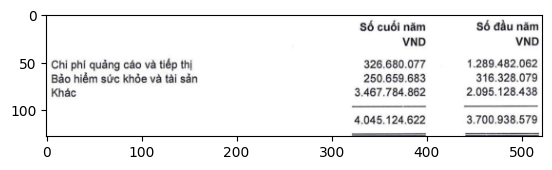

In [46]:
i = 10
data_path = image_path
file_name_sample = all_data.iloc[i][0]
image_input = Image.open(data_path + file_name_sample + '.png').convert('RGB')
plt.imshow(image_input)

In [60]:
with open('test_name.txt', 'r') as file:
    filenames_train = [line.strip() for line in file.readlines()]
filenames_train.sort()
print(len(filenames_train))

204


In [63]:
test_df  = pd.DataFrame()
for filename in filenames_train:
  test = all_data[all_data['0'] == filename]
  if len(test) == 1 :
    test_df = pd.concat([test_df, test], axis=0)
  else:
    filename_2 = filename + '_'
    test_1 =all_data[all_data['0'] == filename_2]
    if len(test_1) == 1 :
      test_df = pd.concat([test_df, test_1], axis=0)
    else:
      print(f'{filename}')

page_image_ricons24_4


In [64]:
i = 0
len(test_df)

203

1
h_original : 93 , w_original : 441


<ipython-input-50-26a68fc2b7ac>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  file_name_sample = test_df.iloc[i][0]


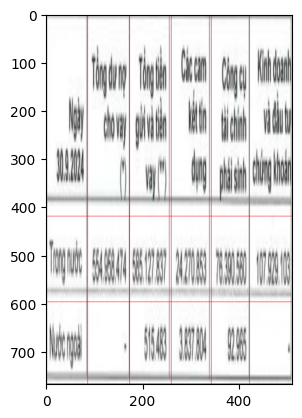

<ipython-input-22-a6dd58ab48ee>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rois_1 = torch.tensor(rois[0])


NameError: name 'teds' is not defined

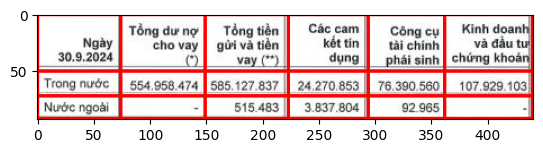

In [50]:

i = i +1
print(i)

file_name_sample = test_df.iloc[i][0]
image_input = Image.open(image_path + file_name_sample + '.png').convert('RGB')
image_test = image_input.copy()
h_original , w_original, c = np.array(image_test).shape
print(f'h_original : {h_original} , w_original : {w_original}')
if (h_original > 512):
    threshold_heatmap_row = 0.5
else :
    threshold_heatmap_row = 0.2
if (w_original > 400):
    threshold_heatmap_col = 0.6
else:
    threshold_heatmap_col = 0.2

if h_original < 100:
    threshold_contour_row = 10
elif h_original > 512:
    threshold_contour_row = 5
else:
    threshold_contour_row = 10
if w_original> 100:
    threshold_contour_col = 10
else :
    threshold_contour_col = 10
# print(f'threshold_contour_row {threshold_contour_row}')
image = np.array(image_test)
image_input = cv2.resize(image, (W_SHAPE, H_SHAPE))
image_input = image_input.astype('float')
image_input = np.array(image_input,dtype= np.float32)/255.0
image_tensor =  torch.from_numpy(image_input)
image_tensor = image_tensor.permute(2,0,1)
image_tensor = torch.unsqueeze(image_tensor, dim = 0)
image_tensor.shape
# image_tensor.to(device)
a,b = split_task(image_tensor.to(device))
row_list_ = get_row_pred_line(a)
row_list_ = sorted(row_list_)
row_list_.insert(0, 1)
row_list_.append(H_SHAPE-1)
col_list_ = get_col_pred_line(b)
# print(row_list_)
col_list_ = sorted(col_list_)
col_list_.insert(0, 1)
col_list_.append(W_SHAPE-1)  # add last column
show_line_pred(row_list_, col_list_, image)
cell_bbox_ = get_pred_bbox_list(row_list_ , col_list_)

bbox_input =  torch.from_numpy(np.array([cell_bbox_]))
# image_input_ = image_tensor_merge.to(device)
# bbox_input = bbox_input.to(device)
row_pred, col_pred = merge_task(image_tensor.to(device), bbox_input.to(device))
last_cell = bbox_input.numpy()[-1]
num_row, num_col =  last_cell[-1][0] , last_cell[-1][1]
row_merge , col_merge  = get_final_pred_merge(row_pred, col_pred, num_row, num_col)
table_dict  = get_table(row_merge, col_merge, np.array(cell_bbox_) )
show_final_result_v2(image , table_dict)
html_pred = generate_html_table(table_dict)
html_pred = "<html><body>" + html_pred + "</body></html>"
html_pred.replace("table border='1'", "table")
html_gt = gen_html_gt(np.array(cell_bbox_))
html_gt = "<html><body>" + html_gt + "</body></html>"
html_gt.replace("table border='1'", "table")


score = teds(html_gt, html_pred)
print(score)




# teds

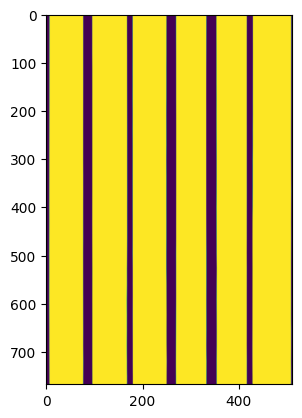

In [ ]:
tmp = get_heatmap_split(b)

In [51]:
from table_recognition_metric import TEDS

teds = TEDS(structure_only=True)

In [ ]:
html_pred = generate_html_table(table_dict)
html_pred = "<html><body>" + html_pred + "</body></html>"
html_pred.replace("table border='1'", "table")
html_gt = gen_html_gt(np.array(cell_bbox_))
html_gt = "<html><body>" + html_gt + "</body></html>"
html_gt.replace("table border='1'", "table")


score = teds(html_gt, html_pred)
print(score)

1.0


In [65]:
score_list = []

In [66]:
score_list = []
score_list_simple = []
score_list_complex = []
for i in range(len(test_df)):
  print(i)


  file_name_sample = all_data.iloc[i][0]
  image_input = Image.open(image_path + file_name_sample + '.png').convert('RGB')
  image_test = image_input.copy()
  h_original , w_original, c = np.array(image_test).shape
  print(f'h_original : {h_original} , w_original : {w_original}')
  if (h_original > 512):
      threshold_heatmap_row = 0.5
  else :
      threshold_heatmap_row = 0.2
  if (w_original > 400):
      threshold_heatmap_col = 0.5
  else:
      threshold_heatmap_col = 0.2

  if h_original < 100:
      threshold_contour_row = 10
  elif h_original > 512:
      threshold_contour_row = 5
  else:
      threshold_contour_row = 10
  if w_original> 100:
      threshold_contour_col = 10
  else :
      threshold_contour_col = 10
  # print(f'threshold_contour_row {threshold_contour_row}')
  image = np.array(image_test)
  image_input = cv2.resize(image, (W_SHAPE, H_SHAPE))
  image_input = image_input.astype('float')
  image_input = np.array(image_input,dtype= np.float32)/255.0
  image_tensor =  torch.from_numpy(image_input)
  image_tensor = image_tensor.permute(2,0,1)
  image_tensor = torch.unsqueeze(image_tensor, dim = 0)
  image_tensor.shape
  # image_tensor.to(device)
  a,b = split_task(image_tensor.to(device))
  row_list_ = get_row_pred_line(a)
  row_list_ = sorted(row_list_)
  row_list_.insert(0, 1)
  row_list_.append(H_SHAPE-1)
  col_list_ = get_col_pred_line(b)
  # print(row_list_)
  col_list_ = sorted(col_list_)
  col_list_.insert(0, 1)
  col_list_.append(W_SHAPE-1)  # add last column
  # show_line_pred(row_list_, col_list_, image)
  cell_bbox_ = get_pred_bbox_list(row_list_ , col_list_)

  bbox_input =  torch.from_numpy(np.array([cell_bbox_]))
  # image_input_ = image_tensor_merge.to(device)
  # bbox_input = bbox_input.to(device)
  row_pred, col_pred = merge_task(image_tensor.to(device), bbox_input.to(device))
  last_cell = bbox_input.numpy()[-1]
  num_row, num_col =  last_cell[-1][0] , last_cell[-1][1]
  row_merge , col_merge  = get_final_pred_merge(row_pred, col_pred, num_row, num_col)
  table_dict  = get_table(row_merge, col_merge, np.array(cell_bbox_) )
  ########### get table_dict_gt ############
  cell_bbox_gt = all_data.iloc[i][1]
  bbox_single_gt = convert_String_to_array(cell_bbox_gt)
  bbox_data_original_list = []
  for bbox in bbox_single_gt:
      row_idx, col_idx, x1_512 , y1_512 , x2_512 , y2_512 = bbox
      x1_original = int(x1_512 * w_original / 512)
      y1_original = int(y1_512 * h_original / 512)
      x2_original = int(x2_512 * w_original / 512)
      y2_original = int(y2_512 * h_original / 512)
      bbox_data_original_list.append([row_idx, col_idx, x1_original, y1_original, x2_original, y2_original])
  bbox_data_original_array = np.array(bbox_data_original_list)
  row_gt = np.load(matrix_row_path + file_name_sample + '.npy')
  row_gt_1 = np.reshape(row_gt, -1)
  col_gt = np.load(matrix_col_path + file_name_sample + '.npy')
  col_gt_1 = np.reshape(col_gt, -1)
  table_dict_gt = get_table(row_gt, col_gt, bbox_data_original_array)
  html_gt = generate_html_table(table_dict_gt)
  html_gt = "<html><body>" + html_gt + "</body></html>"
  html_gt.replace("table border='1'", "table")

  ######## TEDS score #############
  html_pred = generate_html_table(table_dict)
  html_pred = "<html><body>" + html_pred + "</body></html>"
  html_pred.replace("table border='1'", "table")

  score = teds(html_gt, html_pred)
  print(score)
  score_list.append(score)
  if np.sum(row_gt_1) == 0 and np.sum(col_gt_1) == 0:
    score_list_simple.append(score)
  else:
    score_list_complex.append(score)

0
h_original : 396 , w_original : 566


<ipython-input-66-41360a4b4e1f>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  file_name_sample = all_data.iloc[i][0]
<ipython-input-22-a6dd58ab48ee>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rois_1 = torch.tensor(rois[0])
<ipython-input-66-41360a4b4e1f>:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_bbox_gt = all_data.iloc[i][1]


0.927710843373494
1
h_original : 118 , w_original : 406
1.0
2
h_original : 126 , w_original : 536
1.0
3
h_original : 68 , w_original : 529
1.0
4
h_original : 380 , w_original : 847
1.0
5
h_original : 135 , w_original : 544
1.0
6
h_original : 80 , w_original : 531
1.0
7
h_original : 160 , w_original : 542
1.0
8
h_original : 158 , w_original : 545
1.0
9
h_original : 122 , w_original : 525
1.0
10
h_original : 128 , w_original : 522
1.0
11
h_original : 112 , w_original : 528
1.0
12
h_original : 130 , w_original : 530
1.0
13
h_original : 322 , w_original : 856
1.0
14
h_original : 274 , w_original : 537
1.0
15
h_original : 135 , w_original : 519
1.0
16
h_original : 135 , w_original : 527
1.0
17
h_original : 148 , w_original : 543
1.0
18
h_original : 188 , w_original : 546
1.0
19
h_original : 153 , w_original : 530
1.0
20
h_original : 132 , w_original : 573
1.0
21
h_original : 172 , w_original : 575
1.0
22
h_original : 136 , w_original : 556
1.0
23
h_original : 128 , w_original : 552
1.0
24
h

In [67]:
import numpy as np

# Assuming score_list is defined in the previous code
mean_score_all = np.mean(score_list)
mean_score_simple = np.mean(score_list_simple)
mean_score_complex = np.mean(score_list_complex)
print(f"Mean score all: {mean_score_all}")
print(f"Mean score simple: {mean_score_simple}")
print(f"Mean score complex: {mean_score_complex}")

Mean score all: 0.983827557766143
Mean score simple: 0.9922876602564101
Mean score complex: 0.9631791720271858


In [69]:
len(score_list_simple)

144

In [70]:
len(score_list_complex)

59

# cell measure

In [ ]:
from scipy.optimize import linear_sum_assignment

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)
    if inter_area == 0:
        return 0.0

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union_area = boxA_area + boxB_area - inter_area

    return inter_area / union_area

In [ ]:
score_list = []
precision_05 = []
recall_05 = []
f1_05 = []

precision_07 = []
recall_07 = []
f1_07 = []

precision_09 = []
recall_09 = []
f1_09 = []
for i in range(len(test_df)):
  print(i)


  file_name_sample = all_data.iloc[i][0]
  image_input = Image.open(image_path + file_name_sample + '.png').convert('RGB')
  image_test = image_input.copy()
  h_original , w_original, c = np.array(image_test).shape
  # print(f'h_original : {h_original} , w_original : {w_original}')
  if (h_original > 512):
      threshold_heatmap_row = 0.5
  else :
      threshold_heatmap_row = 0.2
  if (w_original > 400):
      threshold_heatmap_col = 0.5
  else:
      threshold_heatmap_col = 0.2

  if h_original < 100:
      threshold_contour_row = 10
  elif h_original > 512:
      threshold_contour_row = 5
  else:
      threshold_contour_row = 10
  if w_original> 100:
      threshold_contour_col = 10
  else :
      threshold_contour_col = 10
  # print(f'threshold_contour_row {threshold_contour_row}')
  image = np.array(image_test)
  image_input = cv2.resize(image, (W_SHAPE, H_SHAPE))
  image_input = image_input.astype('float')
  image_input = np.array(image_input,dtype= np.float32)/255.0
  image_tensor =  torch.from_numpy(image_input)
  image_tensor = image_tensor.permute(2,0,1)
  image_tensor = torch.unsqueeze(image_tensor, dim = 0)
  image_tensor.shape
  # image_tensor.to(device)
  a,b = split_task(image_tensor.to(device))
  row_list_ = get_row_pred_line(a)
  row_list_ = sorted(row_list_)
  row_list_.insert(0, 1)
  row_list_.append(H_SHAPE-1)
  col_list_ = get_col_pred_line(b)
  # print(row_list_)
  col_list_ = sorted(col_list_)
  col_list_.insert(0, 1)
  col_list_.append(W_SHAPE-1)  # add last column
  # show_line_pred(row_list_, col_list_, image)
  cell_bbox_ = get_pred_bbox_list(row_list_ , col_list_)

  bbox_input =  torch.from_numpy(np.array([cell_bbox_]))
  # image_input_ = image_tensor_merge.to(device)
  # bbox_input = bbox_input.to(device)
  row_pred, col_pred = merge_task(image_tensor.to(device), bbox_input.to(device))
  last_cell = bbox_input.numpy()[-1]
  num_row, num_col =  last_cell[-1][0] , last_cell[-1][1]
  row_merge , col_merge  = get_final_pred_merge(row_pred, col_pred, num_row, num_col)
  table_dict_pred  = get_table(row_merge, col_merge, np.array(cell_bbox_) )
  ########### get table_dict_gt ############
  cell_bbox_gt = all_data.iloc[i][1]
  bbox_single_gt = convert_String_to_array(cell_bbox_gt)
  bbox_data_original_list = []
  for bbox in bbox_single_gt:
      row_idx, col_idx, x1_512 , y1_512 , x2_512 , y2_512 = bbox
      x1_original = int(x1_512 * w_original / 512)
      y1_original = int(y1_512 * h_original / 512)
      x2_original = int(x2_512 * w_original / 512)
      y2_original = int(y2_512 * h_original / 512)
      bbox_data_original_list.append([row_idx, col_idx, x1_original, y1_original, x2_original, y2_original])
  bbox_data_original_array = np.array(bbox_data_original_list)
  row_gt = np.load(matrix_row_path + file_name_sample + '.npy')
  row_gt_1 = np.reshape(row_gt, -1)
  col_gt = np.load(matrix_col_path + file_name_sample + '.npy')
  col_gt_1 = np.reshape(col_gt, -1)
  table_dict_gt = get_table(row_gt, col_gt, bbox_data_original_array)
  ######### iou #############
  table_image = np.array(image_test)
  for cell in table_dict_pred:
      bbox = cell['bbox']
      x1_512 , y1_768 , x2_512, y2_768 = bbox
      x1_ori = int(x1_512/W_SHAPE * w_original)
      y1_ori = int(y1_768/H_SHAPE * h_original)
      x2_ori = int(x2_512/W_SHAPE * w_original)
      y2_ori = int(y2_768/H_SHAPE * h_original)
      cell['bbox'] = [x1_ori, y1_ori, x2_ori, y2_ori]

  iou_matrix  = np.zeros((len(table_dict_pred), len(table_dict_gt)))
  for i , cell_gt in enumerate(table_dict_gt):
    for j , cell_pred in enumerate(table_dict_pred):
      iou_matrix[j,i] = compute_iou(cell_gt['bbox'], cell_pred['bbox'])
  gt_idx , pred_idx = linear_sum_assignment(-iou_matrix)

  # iou > 0.5
  threshold_05 = 0.5
  tp_05 = 0
  fp_05 = 0
  fn_05 = 0
  for i,j in zip(gt_idx, pred_idx):
    if iou_matrix[i,j] > threshold_05:
      tp_05 = tp_05 + 1
    else:
      fp_05 = fp_05 + 1
  fn_05 = len(table_dict_gt) - tp_05

  precision_05_score = tp_05 / (tp_05 + fp_05)
  recall_05_score = tp_05 / (tp_05 + fn_05)
  f1_05_score = 2 * (precision_05_score * recall_05_score) / (precision_05_score + recall_05_score)
  precision_05.append(precision_05_score)
  recall_05.append(recall_05_score)
  f1_05.append(f1_05_score)

  # iou > 0.7
  threshold_07 = 0.7
  tp_07 = 0
  fp_07 = 0
  fn_07 = 0
  for i,j in zip(gt_idx, pred_idx):
    if iou_matrix[i,j] > threshold_07:
      tp_07 = tp_07 + 1
    else:
      fp_07 = fp_07 + 1
  fn_07 = len(table_dict_gt) - tp_07
  precision_07_score = tp_07 / (tp_07 + fp_07)
  recall_07_score = tp_07 / (tp_07 + fn_07)
  f1_07_score = 2 * (precision_07_score * recall_07_score) / (precision_07_score + recall_07_score)
  precision_07.append(precision_07_score)
  recall_07.append(recall_07_score)
  f1_07.append(f1_07_score)

  # iou > 0.9
  threshold_09 = 0.9
  tp_09 = 0
  fp_09 = 0
  fn_09 = 0
  for i,j in zip(gt_idx, pred_idx):
    if iou_matrix[i,j] > threshold_09:
      tp_09 = tp_09 + 1
    else:
      fp_09 = fp_09 + 1
  fn_09 = len(table_dict_gt) - tp_09
  precision_09_score = tp_09 / (tp_09 + fp_09)
  recall_09_score = tp_09 / (tp_09 + fn_09)
  f1_09_score = 2 * (precision_09_score * recall_09_score) / (precision_09_score + recall_09_score)
  precision_09.append(precision_09_score)
  recall_09.append(recall_09_score)
  f1_09.append(f1_09_score)

0


<ipython-input-79-4839db5a1638>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  file_name_sample = all_data.iloc[i][0]
<ipython-input-22-a6dd58ab48ee>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rois_1 = torch.tensor(rois[0])
<ipython-input-79-4839db5a1638>:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_bbox_gt = all_data.iloc[i][1]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202


In [ ]:
mean_precision_05 = np.mean(precision_05)
mean_recall_05 = np.mean(recall_05)
mean_f1_05 = np.mean(f1_05)
print(f'mean_precision_05 : {mean_precision_05}')
print(f'mean_recall_05 : {mean_recall_05}')
print(f'mean_f1_05 : {mean_f1_05}')
mean_precision_07 = np.mean(precision_07)
mean_recall_07 = np.mean(recall_07)
mean_f1_07 = np.mean(f1_07)
print(f'mean_precision_07 : {mean_precision_07}')
print(f'mean_recall_07 : {mean_recall_07}')
print(f'mean_f1_07 : {mean_f1_07}')
mean_precision_09 = np.mean(precision_09)
mean_recall_09 = np.mean(recall_09)
mean_f1_09 = np.mean(f1_09)
print(f'mean_precision_09 : {mean_precision_09}')
print(f'mean_recall_09 : {mean_recall_09}')
print(f'mean_f1_09 : {mean_f1_09}')



mean_precision_05 : 0.9861749431831568
mean_recall_05 : 0.9831604879125037
mean_f1_05 : 0.9846007442604814
mean_precision_07 : 0.9726171817306467
mean_recall_07 : 0.9698733680303908
mean_f1_07 : 0.9711860402995612
mean_precision_09 : 0.9219512749433094
mean_recall_09 : 0.9195722780126382
mean_f1_09 : 0.9207085536203258


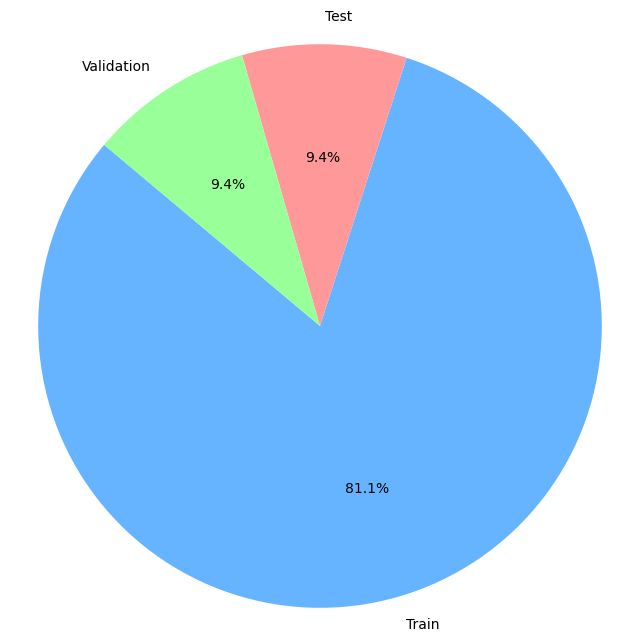

In [ ]:
labels = ['Train', 'Test', 'Validation']
sizes = [91596, 10656, 10635]
colors = ['#66b3ff', '#ff9999', '#99ff99']

# Vẽ biểu đồ hình tròn
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
# plt.title('Tỷ lệ phân bố hình ảnh bảng dữ liệu trong các tập Train, Test và Validation')
plt.axis('equal')  # Đảm bảo hình tròn là hình tròn thật
plt.show()

# td install

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

# td using

In [ ]:
!pip install jdeskew

In [ ]:
!pip install paddlepaddle
!pip install paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 5.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=e9293487e020a34980f8dfa4cb852a9f48313568092d0fc45ae3cc7e91d6d4e2
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
from jdeskew.estimator import get_angle
from jdeskew.utility import rotate

In [ ]:
from paddleocr import PaddleOCR, draw_ocr
import openpyxl
import pandas as pd
from openpyxl import load_workbook
ocr = PaddleOCR(use_angle_cls=True, lang="en")
ocr_vn  = PaddleOCR(use_angle_cls=True, lang='vi')

In [ ]:
import logging
logging.getLogger("ppocr").setLevel(logging.ERROR)
logging.getLogger("paddle").setLevel(logging.ERROR)

In [ ]:
from ultralytics import YOLO
model_td_path = '/content/best.pt'
model_TD = YOLO(model_td_path)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



0: 640x512 4 tables, 54.1ms
Speed: 3.0ms preprocess, 54.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)


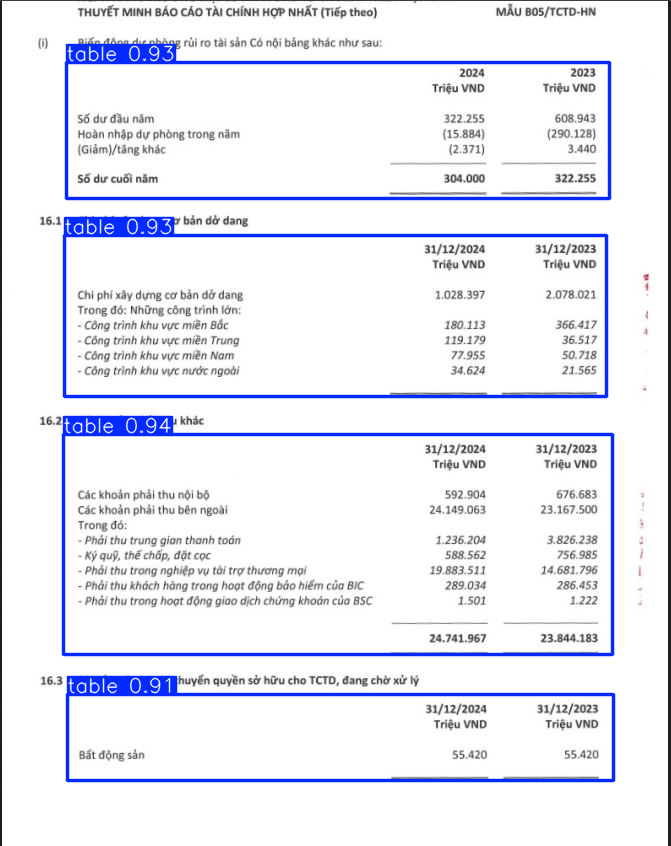

In [ ]:
page_image = Image.open('/content/Capture.JPG')
image_full_page = page_image
TD_reseults = model_TD(image_full_page)
TD_bbox = TD_reseults[0].boxes.xyxy.cpu().numpy()
image_full_page_np  = np.array(image_full_page)
table_list = []
for i in range(int(TD_bbox.shape[0])):
  bbox_sub = TD_bbox[i,:]
  x1 = int(bbox_sub[0] -5)
  y1 = int(bbox_sub[1]-5)
  x2 = int(bbox_sub[2]+5)
  y2 = int(bbox_sub[3]+5)
  table_list.append(image_full_page_np[y1:y2,x1:x2,:])
for r in TD_reseults:
  r.show()

h_original : 96 , w_original : 556
num row : 1 ,  num col :2


,31/12/2024Triệu VND,31/12/2023Triệu VND
Bất động sản,55.420,55.420


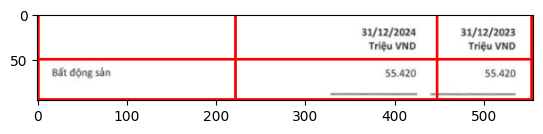

In [ ]:
image_test = table_list[3]
angle = get_angle(np.array(image_test))

(h, w) = image_test.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)

image_test = cv2.warpAffine(image_test, M, (w, h),flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
# print(f' shape of original image {np.array(image_test).shape}')
# with open(html_path + file_name + '.html', 'r') as f:
#     html_code = f.read()
#################
h_original , w_original, c = np.array(image_test).shape
print(f'h_original : {h_original} , w_original : {w_original}')
if (h_original > 512):
    threshold_heatmap_row = 0.8
else :
    threshold_heatmap_row = 0.7
if (w_original > 400):
    threshold_heatmap_col = 0.4
else:
    threshold_heatmap_col = 0.2

if h_original < 100:
    threshold_contour_row = 15
elif h_original > 512:
    threshold_contour_row = 2
else:
    threshold_contour_row = 10
if w_original> 100:
    threshold_contour_col = 15
else :
    threshold_contour_col = 10
# print(f'threshold_contour_row {threshold_contour_row}')
image = np.array(image_test)
image_input = cv2.resize(image, (W_SHAPE, H_SHAPE))
image_input = image_input.astype('float')
image_input = np.array(image_input,dtype= np.float32)/255.0
image_tensor =  torch.from_numpy(image_input)
image_tensor = image_tensor.permute(2,0,1)
image_tensor = torch.unsqueeze(image_tensor, dim = 0)
image_tensor.shape
# image_tensor.to(device)
a,b = split_task(image_tensor.to(device))
row_list_ = get_row_pred_line(a)
row_list_ = sorted(row_list_)
row_list_.insert(0, 1)
row_list_.append(H_SHAPE-1)
col_list_ = get_col_pred_line(b)
# print(row_list_)
col_list_ = sorted(col_list_)
col_list_.insert(0, 1)
col_list_.append(W_SHAPE-1)  # add last column
# show_line_pred(row_list_, col_list_, image)
cell_bbox_ = get_pred_bbox_list(row_list_ , col_list_)

bbox_input =  torch.from_numpy(np.array([cell_bbox_]))
# image_input_ = image_tensor_merge.to(device)
# bbox_input = bbox_input.to(device)
row_pred, col_pred = merge_task(image_tensor.to(device), bbox_input.to(device))
last_cell = bbox_input.numpy()[-1]
num_row, num_col =  last_cell[-1][0] , last_cell[-1][1]
row_merge , col_merge  = get_final_pred_merge(row_pred, col_pred, num_row, num_col)
table_dict  = get_table(row_merge, col_merge, np.array(cell_bbox_) )
show_final_result_v2(image , table_dict)
table_dict_content = get_content(table_dict , image_test , 'en')
print(f'num row : {num_row} ,  num col :{num_col}')
html_pred = get_html(table_dict_content , num_row, num_col)
display(HTML(html_pred))

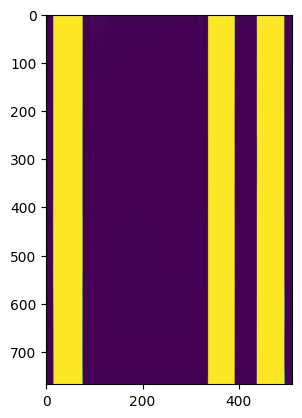

In [ ]:
tmp = get_heatmap_split(b)

In [ ]:
table_dict_content

[{'row': [np.int64(0)], 'col': [np.int64(0)], 'content': ' \n\x0c'},
 {'row': [np.int64(0)], 'col': [np.int64(1)], 'content': 'Năm 2024\n\x0c'},
 {'row': [np.int64(0)], 'col': [np.int64(2)], 'content': 'Năm 2023\n\x0c'},
 {'row': [np.int64(1)],
  'col': [np.int64(0)],
  'content': 'Lợi nhuận năm trước chuyển sang.\n\x0c'},
 {'row': [np.int64(1)],
  'col': [np.int64(1)],
  'content': '19.890.428.760\n\x0c'},
 {'row': [np.int64(1)],
  'col': [np.int64(2)],
  'content': '24.547.212.254\n\x0c'},
 {'row': [np.int64(2)],
  'col': [np.int64(0)],
  'content': 'Lợi nhuận sau thuế Thu nhập doanh nghiệp\n\x0c'},
 {'row': [np.int64(2)],
  'col': [np.int64(1)],
  'content': 'Š.799.681.853\n\x0c'},
 {'row': [np.int64(2)],
  'col': [np.int64(2)],
  'content': '3.936.889.861\n\x0c'},
 {'row': [np.int64(3)],
  'col': [np.int64(0)],
  'content': 'Phân phối lợi nhuận năm trước (*)\n\x0c'},
 {'row': [np.int64(3)],
  'col': [np.int64(1)],
  'content': '6.261.460.000\n\x0c'},
 {'row': [np.int64(3)],
  'col'